<a href="https://colab.research.google.com/github/DA-CristianGutierrez/Analysis-mobility_economy/blob/main/S5%20ladb_mobility_economy_project_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

**Evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajaremos con datos reales de TomTom Traffic Index y OECD Cities, que debemos limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.



In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# mostrar las primeras 5 fila
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


In [ ]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo object.
- Estas columnas requieren conversión a tipo date.
- No hay datos ausentes en alguna columna.

In [ ]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)` son de tipo object.
- Se debe hacer la conversión de estas columnas a tipo float.
- No hay datos ausentes en alguna columna.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

- Cambiar los nombres de las columnas para que tengan el formato `snake_case`.



In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns=\
                    {'Country':'country',\
                     'UpdateTimeUTC':'update_time_utc',\
                     'UpdateTimeUTCWeekAgo':'update_time_utc_week_ago',\
                     'JamsDelay': 'jams_delay',\
                     'TrafficIndexLive': 'traffic_index_live',\
                     'JamsLengthInKms': 'jams_length_kms',\
                     'JamsCount': 'jams_count',\
                     'TrafficIndexWeekAgo': 'traffic_index_week_ago',\
                     'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',\
                     'TravelTimeHistoricPer10KmsMins': 'travel_time_hist_per_10kms_mins',\
                     'MinsDelay': 'mins_delay',\
                     'City':'city'})


# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns=\
                 {'City GDP/capita': 'city_gdp_capita',\
                  'Unemployment %':'unemployment_pct',\
                  'PM2.5 (μg/m³)': 'pm25',\
                  'Population (M)': 'population_m',\
                  'Year': 'year',\
                  'Country':'country',\
                  'City':'city'})
#Se renombra la columna 'Year' para evitar errores al momento de la unión de tablas

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.




In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')


# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [ ]:
# Limpiar separadores y convertir columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita']\
                         .astype(str).str.replace('.', '')\
                         .str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct']\
                         .astype(str).str.replace('%', '')\
                         .str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m']\
                         .astype(str)\
                         .str.replace(',', '.').astype(float)

# Calcular la población total en unidades absolutas (Multiplicar * 1000000)
eco['population'] = eco['population_m']*1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

- Utilizar copias para evitar modificar los datasets originales. (`traffic_2024` y `eco_2024`)

In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = pd.to_datetime(traffic['update_time_utc']).dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtrar los registros del año 2024
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year']==2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad


### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Calcular el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).


In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año

traffic_city_year_2024 =  traffic_2024.groupby(['city','country','year'])\
                    [['jams_delay','traffic_index_live',\
                      'jams_length_kms','jams_count',\
                      'mins_delay','travel_time_live_per_10kms_mins',\
                      'travel_time_hist_per_10kms_mins']].agg('mean')\
                      .reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
# Revisar la nueva variable para confirmar la información que queremos guardar
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

NameError: name 'traffic_city_year_2024' is not defined

La ciudad con el mayor tiempo promedio de tráfico es Ciudad de México (mexico-city, MEX) con un jams_delay promedio de ~2833 minutos.


---

## 🧩Paso 5: Unir movilidad y economía

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Seleccionar solo las **columnas relevantes** de cada dataset



In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')


# Mostrar las primeras 5 filas
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usar las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- **Comparar ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Agregar título y etiquetas a los ejes de los gráficos.

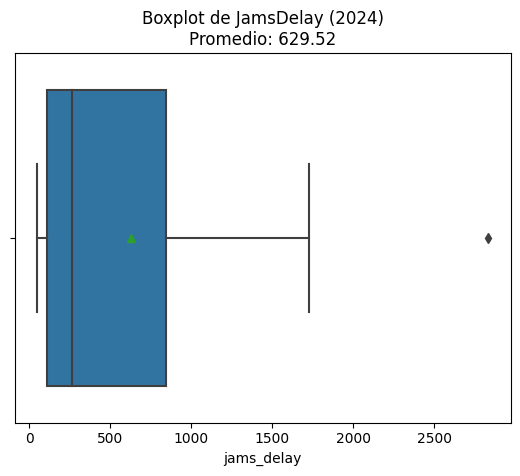

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
sns.boxplot(data=merged, x='jams_delay', showmeans=True)
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()



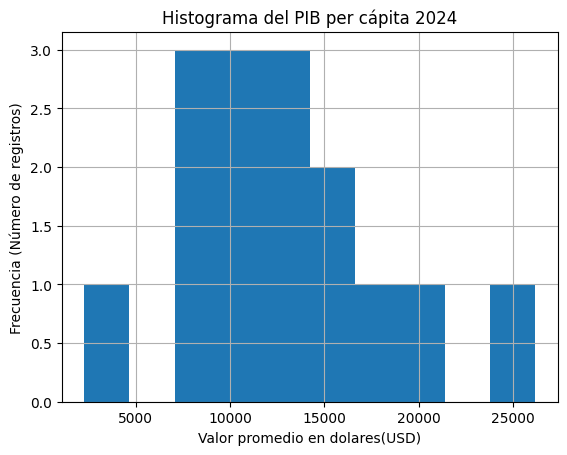

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged['city_gdp_capita'].hist()
plt.title('Histograma del PIB per cápita en América Latina (2024)')
plt.xlabel('Valor promedio en dolares(USD)')
plt.ylabel('Frecuencia (Número de registros)')
plt.show()



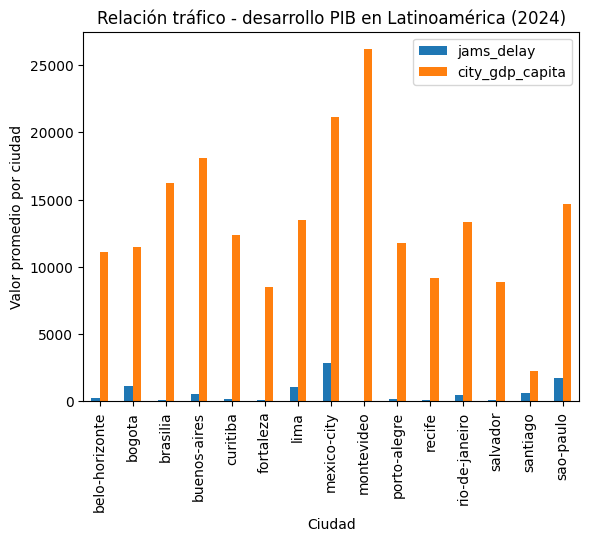

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(kind='bar', x='city', y=['jams_delay', 'city_gdp_capita'])
plt.title('Relación tráfico - desarrollo PIB en Latinoamérica (2024)')
plt.xlabel('Ciudad')
plt.ylabel('Valor promedio por ciudad')
plt.xticks(rotation=90)
plt.show()

Comentarios:

- Aunque algunos paises tienen mayor promedio de tráfico así como desarrollo en PIB, se observa que no en todos se presenta la misma propoción: El país con mayor PIB tiene valores muy bajos en tráfico, mientras que el segundo país con mayor PIB contiene el promedio en tráfico mas alto respecto a los demás paises.
- En conclusión, no hay una relación clara que permita afirmar que la movilidad urbana en varios paises impacte sobre sus actividades de productividad económica.


---

## 🧩Paso 7: Exportar y documentar resultados


### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- No incluir columna inicial con índice en el dataset resultante.


In [ ]:
# Exportar el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

# Resultado del análisis

Inicialmente se exploró la información de dos datasets relacionados con la movilidad urbana y la productividad económica, seguido de una limpieza y formateo estandar para avanzar con el cálculo de métricas; tipos de formato, columnas renombradas.

Se calcularon promedios en columnas clave que representan tiempos de retraso en tráfico y PIB en dolares, teniendo en cuenta 14 principales ciudades latinoamericanas en 2024. Finalmente se realizó el cruce de información entre ambos datasets tomando los valores con coincidencias exactas en ambas fuentes y se revisó la consistencia de la información del nuevo dataset.

Luego del analisis observamos que no existe una estricta relación entre productividad económica y movilidad urbana ya que no existe una proporción uniforme en países que tienen valores similares en una métrica y en otra existen diferencias considerables, por ejemplo entre la ciudad de bogota y belo-horizonte, y entre ciudad-mexico y montevideo.

Es importante mencionar que se detectaron outliers (un promedio de 2500 minutos de retraso en tráfico el cual está muy alejado de los demás registros), así como valores aislados en la distribución del histograma, lo cual puede resultar afectando el analisis.

Es necesario revisar las fuentes de información para descartar impresiciones en los resultados, así como considerar otras variables como el desarrollo de infraestructura en las ciudades evaluadas así como la tendencia en las actividades económicas que se desarrollan respectivamente. De igual manera, considerar una inversión para el desarrollo de infraestructura en ciudades como santiago donde el tráfico es crítico y su baja economía pueda impedir esta mejora.
